# **Contexto e Objetivo**
Desenvolver uma rede neural capaz de identificar qual número está representado em uma imagem, e vamos resolver o mesmo problema utilizando dois frameworks (TensorFlow e PyTorch) usando as imagens do MNIST.

Cada imagem possui 28 x 28 pixels, a rede neural irá analisar a imagem e trazer qual número está nessa imagem

---

# **Estrutura da Atividiade**


| #  | Etapa                             | Objetivo                       |
| -- | --------------------------------- | ------------------------------ |
| 1  | Contexto e objetivo               | Entender o problema            |
| 2  | Importação das bibliotecas        | Preparar o ambiente            |
| 3  | Verificação do ambiente           | Conferir versões e GPU         |
| 4  | Carregamento do MNIST             | Obter os dados                 |
| 5  | Conhecendo os dados               | Entender imagens e classes     |
| 6  | Visualização das imagens          | Enxergar o problema            |
| 7  | Pré-processamento                 | Preparar os dados para a rede  |
| 8  | Separação dos dados               | Treino, validação e teste      |
| 9  | Construção da rede com TensorFlow | Criar a primeira rede          |
| 10 | Treinamento com TensorFlow        | Treinar o modelo               |
| 11 | Avaliação do TensorFlow           | Medir o desempenho             |
| 12 | Construção da rede com PyTorch    | Recriar a mesma arquitetura    |
| 13 | Treinamento com PyTorch           | Entender o loop de treinamento |
| 14 | Avaliação do PyTorch              | Medir o desempenho             |
| 15 | Comparação TensorFlow × PyTorch   | Comparar os frameworks         |
| 16 | Testando novas imagens            | Fazer previsões                |
| 17 | Conclusão                         | Consolidar os aprendizados     |



In [23]:
# 2.Importação das Bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
from sklearn.model_selection import train_test_split

# 2.1.Importação das bibliotecas específicas
from tensorflow import keras
from tensorflow.keras import layers
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [2]:
# 3.Carregando os dados do MNIST
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

from torchvision import datasets

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# 4.Conhecendo os dados
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

np.unique(y_train)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

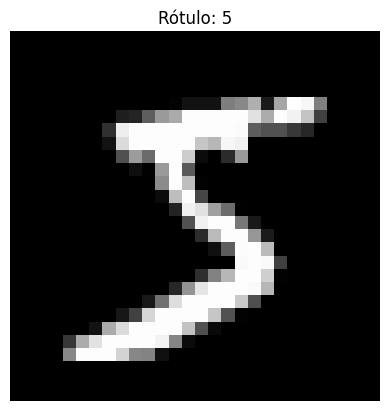


 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 

In [4]:
# 5.Visualização das Imagens

# 5.1.Visualizando uma única imagem
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Rótulo: {y_train[0]}")
plt.axis("off")
plt.show()

# 5.2.Verificando os pixels
print("\n",X_train[0])

# 5.3.Confirmando o tamanho da imagem
print("\nAltura:",X_train[0].shape[0])
print("Largura:", X_train[0].shape[1])


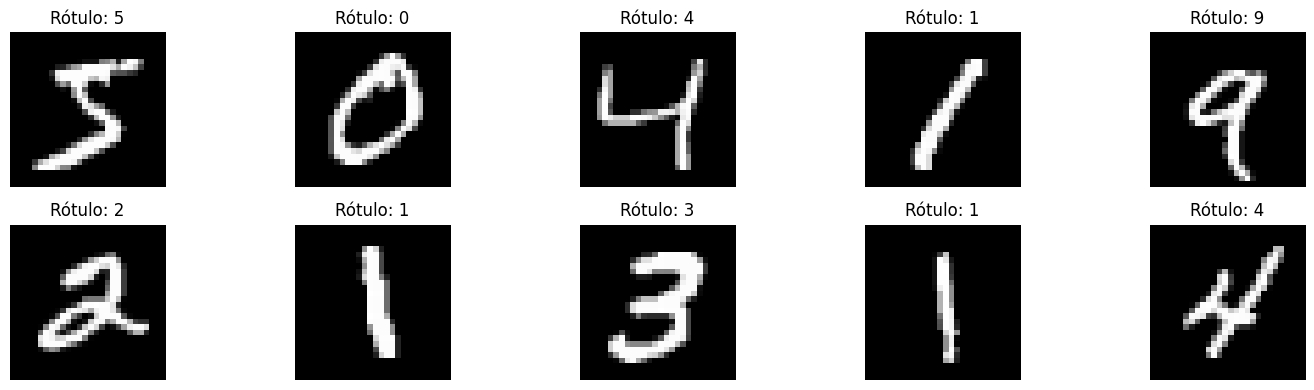

In [5]:
# 5.4.Visualizando várias imagems
plt.figure(figsize=(15,4))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i], cmap="gray")
  plt.title(f"Rótulo: {y_train[i]}")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# 5.5.Verificando a distribuição das classes dos números
valores, quantidades = np.unique(y_train, return_counts=True)

for valor, quantidade in zip(valores,quantidades):
  print(f"Número: {valor}: {quantidade} imagens")

Número: 0: 5923 imagens
Número: 1: 6742 imagens
Número: 2: 5958 imagens
Número: 3: 6131 imagens
Número: 4: 5842 imagens
Número: 5: 5421 imagens
Número: 6: 5918 imagens
Número: 7: 6265 imagens
Número: 8: 5851 imagens
Número: 9: 5949 imagens


In [7]:
# 6.Pré-processamento dos dados

# 6.1.Verificando os valores dos pixels
print("Valor Mínimo:",X_train.min())
print("Valor Máximo:",X_train.max())

# 6.2.Normalizando as imagens
X_train_normalizado = X_train.astype("float32")/255.0
X_test_normalizado = X_test.astype("float32")/255.0

# 6.3.Verificando se a normalização funcionou
print("\nValor Mínimo:",X_train_normalizado.min())
print("Valor Máximo:",X_train_normalizado.max())

# 6.4.Comparando antes e depois da normalização
print("\nAntes da normalização:")
print(X_train[0].min(), X_train[0].max())

print("\nDepois da normalização:")
print(X_train_normalizado[0].min(), X_train_normalizado[0].max())

Valor Mínimo: 0
Valor Máximo: 255

Valor Mínimo: 0.0
Valor Máximo: 1.0

Antes da normalização:
0 255

Depois da normalização:
0.0 1.0


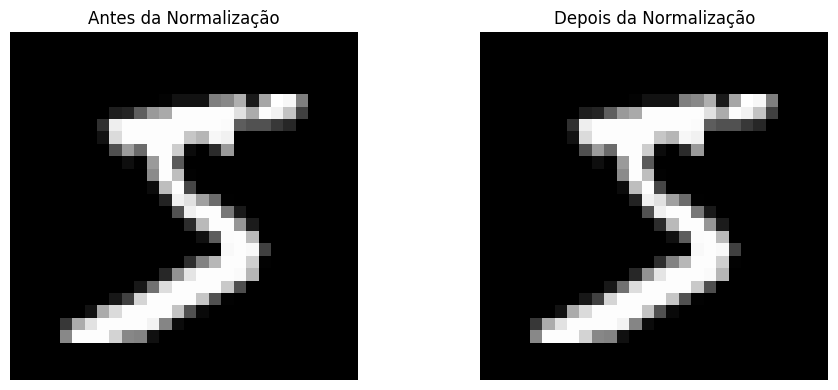

In [8]:
# 6.5.Verificando se a imagem mudou
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(X_train[0], cmap="gray")
plt.title("Antes da Normalização")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(X_train_normalizado[0], cmap="gray")
plt.title("Depois da Normalização")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# 7.Separação dos dados

# 7.1.Separando treinamento e validação
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_normalizado,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# 7.2.Conferindo os tamanhos das divisões
print("Treinamento:",X_train_final.shape)
print("Validação:",X_val.shape)
print("Teste:",X_test_normalizado.shape)

# 7.3.Verificando a distribuição das classes
print("\nTreinamento:")
print(np.unique(y_train_final, return_counts=True))

print("\nValidação:")
print(np.unique(y_val, return_counts=True))

print("\nTeste:")
print(np.unique(y_test, return_counts=True))


Treinamento: (48000, 28, 28)
Validação: (12000, 28, 28)
Teste: (10000, 28, 28)

Treinamento:
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([4738, 5394, 4766, 4905, 4674, 4337, 4734, 5012, 4681, 4759]))

Validação:
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([1185, 1348, 1192, 1226, 1168, 1084, 1184, 1253, 1170, 1190]))

Teste:
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))


In [10]:
# 8.Construção da Rede Neural com TensorFlow

# 8.1.Criando o modelo
modelo_tf = keras.Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# 8.2.Visualizando a arquitetura
modelo_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 9.Treinando com o Tensorflow

# 9.1.Compilando o modelo
modelo_tf.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 9.2.Treinando o modelo
historico_tf = modelo_tf.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8998 - loss: 0.3591 - val_accuracy: 0.9428 - val_loss: 0.1982
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9577 - loss: 0.1453 - val_accuracy: 0.9622 - val_loss: 0.1361
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9697 - loss: 0.1008 - val_accuracy: 0.9652 - val_loss: 0.1193
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9769 - loss: 0.0772 - val_accuracy: 0.9694 - val_loss: 0.1056
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9822 - loss: 0.0596 - val_accuracy: 0.9712 - val_loss: 0.0968
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9858 - loss: 0.0468 - val_accuracy: 0.9702 - val_loss: 0.1010
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9883 - loss: 0.0390 - val_accuracy: 0.9723 - val_loss: 0.0999
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9914 - loss: 0.0298 - val_accuracy: 0

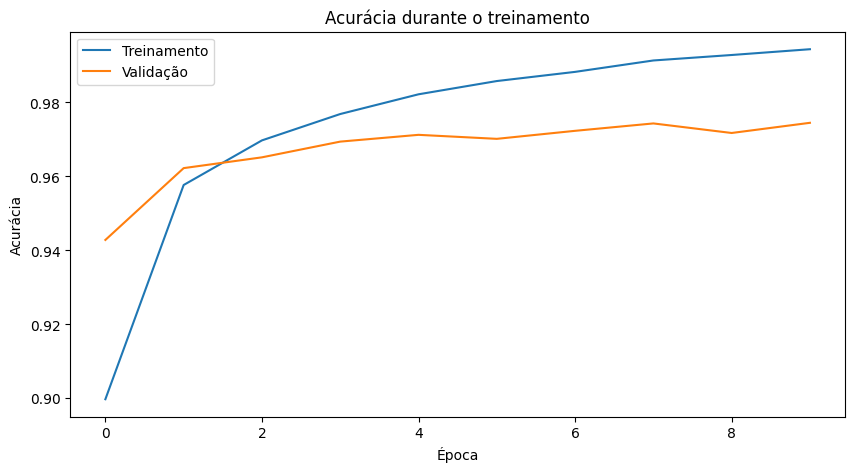

In [12]:
# 9.3.Visualizando o aprendizado
plt.figure(figsize=(10,5))

plt.plot(historico_tf.history["accuracy"], label="Treinamento")
plt.plot(historico_tf.history["val_accuracy"], label="Validação")

plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()

plt.show()

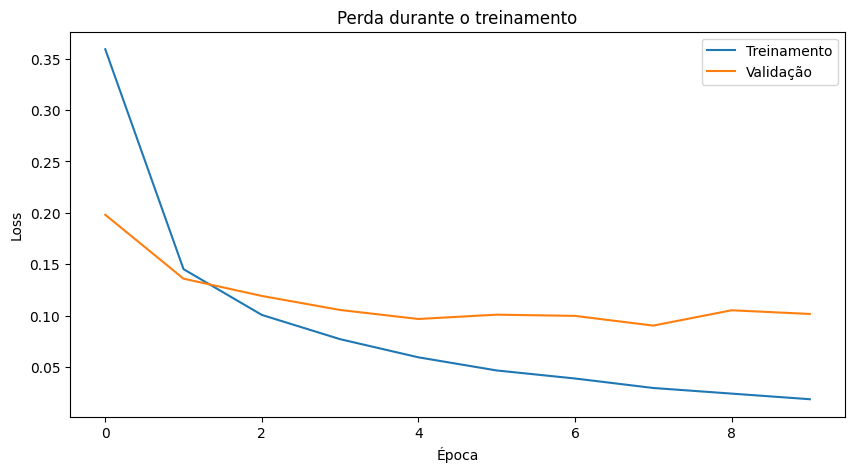

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(historico_tf.history["loss"], label="Treinamento")
plt.plot(historico_tf.history["val_loss"], label="Validação")

plt.title("Perda durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
# 10.Avaliando o modelo com o conjunto de teste
loss_tf, accuracy_tf = modelo_tf.evaluate(
    X_test_normalizado,
    y_test,
    verbose=1
)

print(f"Loss no teste: {loss_tf:.4f}")
print(f"Acurácia no teste: {accuracy_tf:.4f}")

# 10.1.Comparando validação e teste
print(f"\nAcurácia de validação: {historico_tf.history['val_accuracy'][-1]:.4f}")
print(f"Acurácia de teste:     {accuracy_tf:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9773 - loss: 0.0797
Loss no teste: 0.0797
Acurácia no teste: 0.9773

Acurácia de validação: 0.9745
Acurácia de teste:     0.9773


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


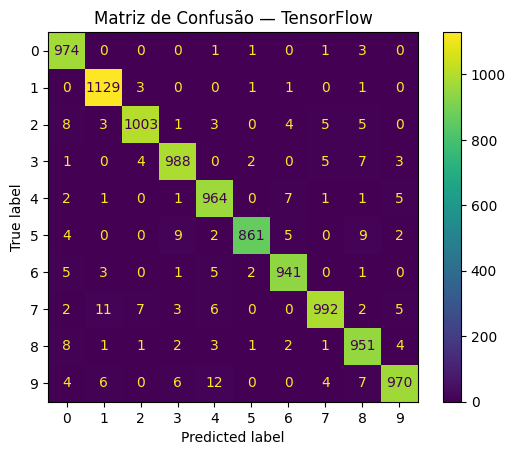

In [15]:
# 10.2.Gerando a matriz de confusão
y_pred_prob = modelo_tf.predict(X_test_normalizado)
y_pred = np.argmax(y_pred_prob, axis=1)

matriz = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=np.arange(10)
)

display.plot()

plt.title("Matriz de Confusão — TensorFlow")
plt.show()

In [16]:
# 10.3.Relatório de Classificação
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9663    0.9939    0.9799       980
           1     0.9783    0.9947    0.9865      1135
           2     0.9853    0.9719    0.9785      1032
           3     0.9773    0.9782    0.9777      1010
           4     0.9679    0.9817    0.9747       982
           5     0.9919    0.9652    0.9784       892
           6     0.9802    0.9823    0.9812       958
           7     0.9832    0.9650    0.9740      1028
           8     0.9635    0.9764    0.9699       974
           9     0.9808    0.9613    0.9710      1009

    accuracy                         0.9773     10000
   macro avg     0.9775    0.9771    0.9772     10000
weighted avg     0.9774    0.9773    0.9773     10000



In [17]:
# 11. Construção da Rede Neural com PyTorch

# 11.1.Verificando se o ambiente possui uma GPU disponível
dispositivo = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo Utilizado:",dispositivo)

Dispositivo Utilizado: cpu


In [18]:
# 11.2.Criando a classe do modelo
class ModeloPyTorch(nn.Module):

  def __init__(self):

    super().__init__()

    self.rede = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10),

    )

  def forward(self, x):
    return self.rede(x)

  # 11.3.Instanciando o modelo
modelo_pt = ModeloPyTorch().to(dispositivo)
print(modelo_pt)

  # 11.4.Conferindo os parâmetros
quantidade_parametros = sum(
      parametro.numel()
      for parametro in modelo_pt.parameters()
)

print("\nTotal de Parâmetros:",quantidade_parametros)

# 11.5.Testando a saída do modelo
imagem_exemplo = torch.tensor(
    X_train_final[0],
    dtype=torch.float32
).unsqueeze(0).to(dispositivo)

saida_exemplo = modelo_pt(imagem_exemplo)

print("\nFormato da entrada:", imagem_exemplo.shape)
print("Formato da saída:", saida_exemplo.shape)

ModeloPyTorch(
  (rede): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total de Parâmetros: 109386

Formato da entrada: torch.Size([1, 28, 28])
Formato da saída: torch.Size([1, 10])


In [29]:
# 12.Preparação dos Dados e Treinamento com PyTorch

# 12.1.Criando os TensorDataset
X_train_tensor = torch.tensor(
    X_train_final,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_final,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)


train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

# 12.2.Criando o DataLoader
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 12.3.Conferindo o DataLoader
for imagens, rotulos in train_loader:
  print("Formato das Imagens:",imagens.shape)
  print("Formato dos Rótulos:",rotulos.shape)
  break

# 12.4.Conferindo a quantidade de batches
print("\nQuantidade de Batches de Treinamento:",len(train_loader))
print("Quantidade de Batches de Validação:",len(val_loader))

# 12.5.Definindo a função de perda
funcao_perda = nn.CrossEntropyLoss()

# 12.6.Definindo o otimizador
otimizador = torch.optim.Adam(
    modelo_pt.parameters(),
    lr=0.001
)

# 12.7.Treinamento completo do nosso modelo

epochs = 10

historico_pt = {
    "loss":[],
    "accuracy":[],
    "val_loss":[],
    "val_accuracy":[]
}

for epoch in range(epochs):
  # ==========================
  # TREINAMENTO
  # ==========================

  modelo_pt.train()

  perda_total=0
  acertos=0
  total=0

  for imagens, rotulos in train_loader:
    imagens=imagens.to(dispositivo)
    rotulos=rotulos.to(dispositivo)

    otimizador.zero_grad()

    saidas = modelo_pt(imagens)

    perda = funcao_perda(saidas, rotulos)

    perda.backward()

    otimizador.step()

    perda_total += perda.item()*imagens.size(0)

    previsoes = torch.argmax(saidas, dim=1)

    acertos += (previsoes == rotulos).sum().item()
    total += rotulos.size(0)

perda_media = perda_total/total
acuracia=acertos/total

# ==========================
# TREINAMENTO
# ==========================

modelo_pt.eval()

perda_val_total=0
acertos_val=0
total_val=0

with torch.no_grad():

  for imagens, rotulos in val_loader:

    imagens = imagens.to(dispositivo)
    rotulos = rotulos.to(dispositivo)

    saidas = modelo_pt(imagens)

    perda_val = funcao_perda(saidas, rotulos)

    perda_val_total += perda_val.item()*imagens.size(0)

    previsoes = torch.argmax(saidas, dim=1)

    acertos_val += (previsoes == rotulos).sum().item()
    total_val += rotulos.size(0)

perda_val_media = perda_val_total/total_val
acuracia_val = acertos_val/total_val

# ==========================
# SALVANDO HISTÓRICO
# ==========================

historico_pt["loss"].append(perda_media)
historico_pt["accuracy"].append(acuracia)

historico_pt["val_loss"].append(perda_val_media)
historico_pt["val_accuracy"].append(acuracia_val)

print(
  f"\nEpoch {epoch + 1}/{epochs} "
  f"- Loss: {perda_media:.4f} "
  f"- Accuracy: {acuracia:.4f} "
  f"- Val Loss: {perda_val_media:.4f} "
  f"- Val Accuracy: {acuracia_val:.4f}"
)

Formato das Imagens: torch.Size([128, 28, 28])
Formato dos Rótulos: torch.Size([128])

Quantidade de Batches de Treinamento: 375
Quantidade de Batches de Validação: 94

Epoch 10/10 - Loss: 0.0065 - Accuracy: 0.9983 - Val Loss: 0.1155 - Val Accuracy: 0.9755


Loss no teste: 0.1041
Acurácia no teste: 0.9770

Acurácia de Validação: 0.9755
Acurácia de teste:     0.9770


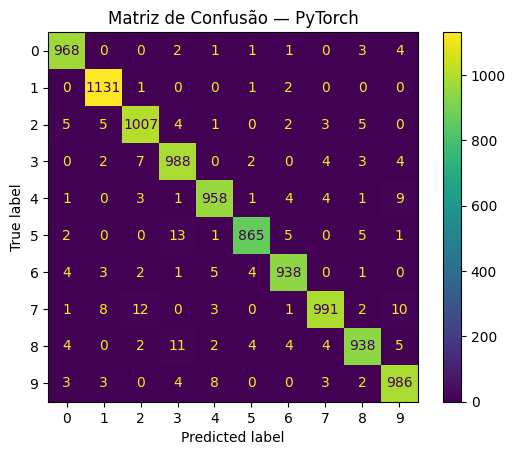

              precision    recall  f1-score   support

           0     0.9798    0.9878    0.9837       980
           1     0.9818    0.9965    0.9891      1135
           2     0.9739    0.9758    0.9748      1032
           3     0.9648    0.9782    0.9715      1010
           4     0.9785    0.9756    0.9771       982
           5     0.9852    0.9697    0.9774       892
           6     0.9801    0.9791    0.9796       958
           7     0.9822    0.9640    0.9730      1028
           8     0.9771    0.9630    0.9700       974
           9     0.9676    0.9772    0.9724      1009

    accuracy                         0.9770     10000
   macro avg     0.9771    0.9767    0.9769     10000
weighted avg     0.9770    0.9770    0.9770     10000



In [38]:
# 13.Avaliação do Modelo em PyTorch

# 13.1.Preparando os dados de teste
X_test_tensor = torch.tensor(
    X_test_normalizado,
    dtype=torch.float32
)

y_test_tensor=torch.tensor(
    y_test,
    dtype=torch.long
)

test_dataset=TensorDataset(
    X_test_tensor,
    y_test_tensor
)

test_loader=DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

# 13.2.Avaliando o modelo
modelo_pt.eval()

perda_teste=0
acertos_teste=0
total_teste=0

todas_previsoes=[]
todos_rotulos=[]

with torch.no_grad():

  for imagens, rotulos in test_loader:

    imagens=imagens.to(dispositivo)
    rotulos=rotulos.to(dispositivo)

    saidas=modelo_pt(imagens)

    perda=funcao_perda(saidas, rotulos)

    perda_teste += perda.item()*imagens.size(0)

    previsoes=torch.argmax(saidas, dim=1)

    acertos_teste += (previsoes == rotulos).sum().item()
    total_teste += rotulos.size(0)

    todas_previsoes.extend(
        previsoes.cpu().numpy()
    )

    todos_rotulos.extend(
        rotulos.cpu().numpy()
    )

# 13.3.Calculando as métricas de avaliação
perda_teste_media=perda_teste/total_teste
acuracia_teste=acertos_teste/total_teste

print(f"Loss no teste: {perda_teste_media:.4f}")
print(f"Acurácia no teste: {acuracia_teste:.4f}")

# 13.4.Comparando a validação e o teste
print(
    f"\nAcurácia de Validação: "
    f"{historico_pt["val_accuracy"][-1]:.4f}"
)

print(
    f"Acurácia de teste:     "
    f"{acuracia_teste:.4f}"
)

# 13.5.Gerando a matriz de Confusão do Modelo
todos_rotulos=np.array(todos_rotulos)
todas_previsoes=np.array(todas_previsoes)

matriz_pt=confusion_matrix(
  todos_rotulos,
  todas_previsoes
)

display = ConfusionMatrixDisplay(
    confusion_matrix=matriz_pt,
    display_labels=np.arange(10)
)

display.plot()

plt.title("Matriz de Confusão — PyTorch")
plt.show()

# 13.6.Gerando o Classification Report do Modelo feito com PyTorch
print(
    classification_report(
        todos_rotulos,
        todas_previsoes,
        digits=4
    )
)

#🔬**Comparando TensorFlow x PyTorch**

Após todas essas linhas de código, podemos colocar os resultados lado a lado

| Métrica         | TensorFlow |    PyTorch |
| --------------- | ---------: | ---------: |
| **Accuracy**    | **97,72%** | **97,70%** |
| Macro Precision |     97,72% | **97,71%** |
| Macro Recall    |     97,71% |     97,67% |
| Macro F1        | **97,71%** |     97,69% |
| Weighted F1     |     97,72% |     97,70% |
| Parâmetros      |    109.386 |    109.386 |

A diferença de acurácia foi:
> 97,72% - 97,70% = 0,02 ponto percentual

Ou seja, praticamente não houve diferença de desempenho no teste

# **🧠 O que esse resultado nos ensina?**

Nosso experimento serviu para mostrar que os dois frameworks conseguiram produzir modelos com desempenho muito semelhante.

Também nos ajuda a concluir que não existe um framework universalmente melhor que o outro. O desempenho de uma implementação depende de vários fatores como: arquitetura, hiperparâmetros, inicialização, dados e procedimento de treinamento.

E se fomos olhar os seguintes dados, podemos verificar que os dois modelos não cometem exatamente os mesmos erros, mesmo possuindo a mesma arquitetura.

| Classe | TensorFlow F1 | PyTorch F1 |
| ------ | ------------: | ---------: |
| 0      |        98,62% |     98,37% |
| 1      |        98,77% | **98,91%** |
| 2      |        97,44% | **97,48%** |
| 3      |    **98,01%** |     97,15% |
| 4      |        97,51% |     97,71% |
| 5      |    **97,76%** |     97,74% |
| 6      |    **98,26%** |     97,96% |
| 7      |    **97,46%** |     97,30% |
| 8      |        96,55% | **97,00%** |
| 9      |        96,69% | **97,24%** |


# **Conclusão Final**

> Os modelos desenvolvidos com TensorFlow e PyTorch apresentaram desempenho muito semelhante no conjunto de teste do MNIST. O modelo TensorFlow alcançou 97,72% de acurácia, enquanto o modelo PyTorch alcançou 97,70%. Ambos utilizaram a mesma arquitetura e 109.386 parâmetros. As pequenas diferenças observadas nas métricas por classe indicam que, apesar da arquitetura equivalente, os modelos podem apresentar padrões de erro distintos.



